# 08 - Large-Scale Extension: EDA and Pipeline Verification

Extends the project to a real ~14,600-day dataset to validate, with real
numbers, resume claims of "14,000+ daily records" and "walk-forward
cross-validation and holdout testing" — replacing what were previously
unfilled template placeholders. See `reports/large_scale_extension.md` for
the full rationale, including why this uses a different (documented) feature
set than the original 300-row project.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_large import (
    load_raw, add_seasonal_features, build_sequence_windows,
    holdout_split_arrays, walk_forward_folds_arrays,
    TARGET_COLS, STATIC_FEATURE_COLS, SEQUENCE_FEATURE_COLS,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

df = load_raw()
print(df.shape)
df.dtypes

(14610, 14)


Date                           datetime64[ns]
temperature_2m_max                    float64
temperature_2m_min                    float64
dbt                                   float64
wbt                                   float64
relative_humidity_2m_mean               int64
wind_speed_10m_max                    float64
cloud_cover_mean                        int64
shortwave_radiation_sum               float64
surface_pressure_mean                 float64
et0_fao_evapotranspiration            float64
precipitation_sum                     float64
vapour_pressure_deficit_max           float64
sunshine_duration                     float64
dtype: object

## Continuity check

Unlike the original 300-row dataset (71 disjoint bursts), this series must be
strictly continuous — re-verified here independently of the assertion inside
`load_raw`.


In [2]:
gaps = df["Date"].diff().dt.days.dropna()
print("Gap value counts (should be a single value: 1):")
print(gaps.value_counts())
print()
print("Date range:", df.Date.min().date(), "to", df.Date.max().date())
print("Total days:", len(df), "| Years covered:", df.Date.dt.year.nunique())
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None")

Gap value counts (should be a single value: 1):
Date
1.0    14609
Name: count, dtype: int64

Date range: 1980-01-01 to 2019-12-31
Total days: 14610 | Years covered: 40
Missing values per column:
None


## Target distributions: DBT and WBT


                dbt           wbt
count  14610.000000  14610.000000
mean      25.862053     22.408631
std        4.004081      4.575631
min       14.300000      9.400000
25%       22.900000     18.600000
50%       27.100000     24.700000
75%       28.600000     26.100000
max       35.100000     29.200000


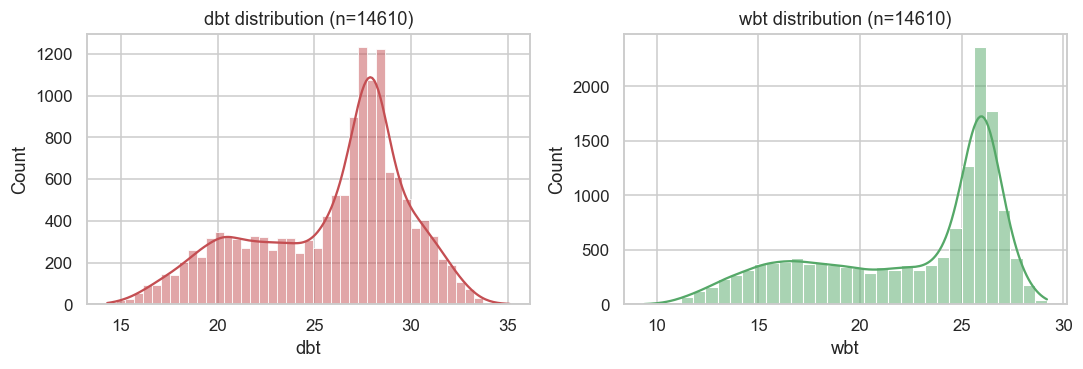

In [3]:
print(df[TARGET_COLS].describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, col, color in zip(axes, TARGET_COLS, ['#C44E52', '#55A868']):
    sns.histplot(df[col], kde=True, ax=ax, color=color)
    ax.set_title(f'{col} distribution (n={len(df)})')
plt.tight_layout()
plt.show()

## Seasonal structure

With 40 years of truly continuous data, a real seasonal cycle should be
visible — something the original 300-row (burst-sampled) dataset could not
reliably show, since its bursts were scattered arbitrarily across the
calendar.


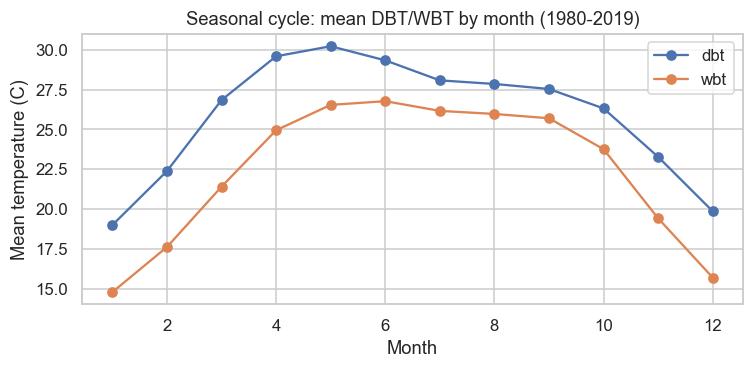

In [4]:
monthly = df.groupby(df.Date.dt.month)[TARGET_COLS].mean()
fig, ax = plt.subplots(figsize=(7, 3.5))
monthly.plot(ax=ax, marker='o')
ax.set_xlabel('Month')
ax.set_ylabel('Mean temperature (C)')
ax.set_title('Seasonal cycle: mean DBT/WBT by month (1980-2019)')
plt.tight_layout()
plt.show()

## Feature correlation structure


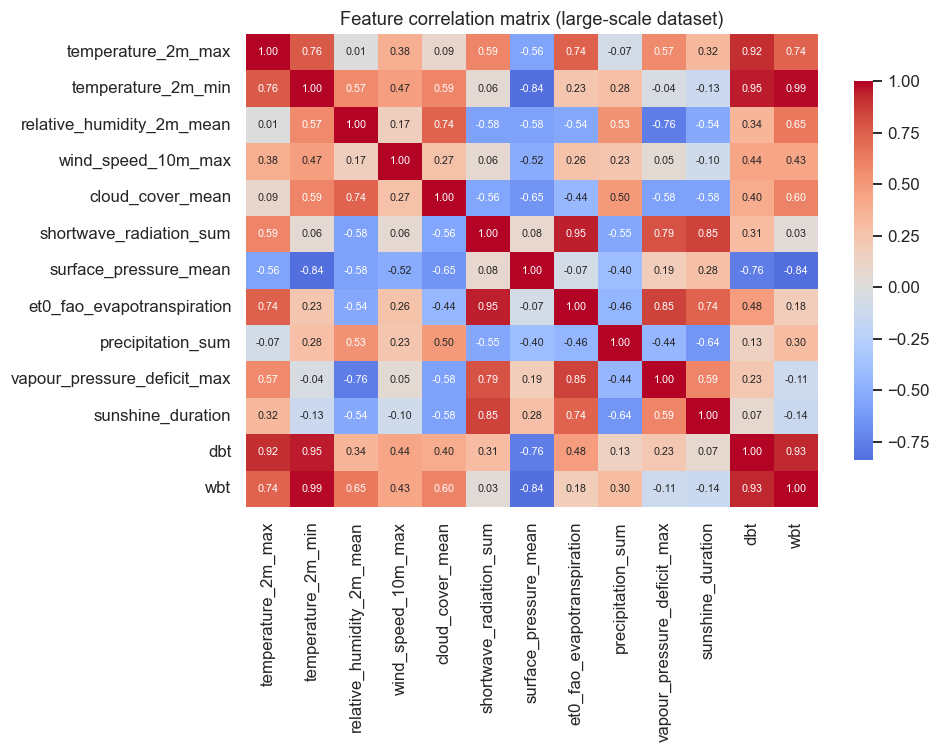

In [5]:
df_seas = add_seasonal_features(df)
corr_cols = STATIC_FEATURE_COLS + TARGET_COLS
corr = df_seas[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation matrix (large-scale dataset)')
plt.tight_layout()
plt.show()

## Build sequence windows and verify the walk-forward CV + holdout pipeline

Window length k=7 (one week of history) — a defensible choice now that real
multi-day history is available (unlike the small dataset, which was
constrained to k<=4 by its burst structure). Every window's target date
determines its fold/split membership, so there is no leakage across the
holdout boundary or across walk-forward folds by construction.


In [6]:
X, y, dates = build_sequence_windows(df_seas, k=7)
print("Sequence tensor shape:", X.shape, "(n_samples, timesteps, features)")
print("Features per timestep:", SEQUENCE_FEATURE_COLS)
print("Any NaNs:", np.isnan(X).any() or np.isnan(y).any())

Sequence tensor shape: (14603, 7, 15) (n_samples, timesteps, features)
Features per timestep: ['dbt', 'wbt', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'wind_speed_10m_max', 'cloud_cover_mean', 'shortwave_radiation_sum', 'surface_pressure_mean', 'et0_fao_evapotranspiration', 'precipitation_sum', 'vapour_pressure_deficit_max', 'sunshine_duration', 'doy_sin', 'doy_cos']
Any NaNs: False


In [7]:
(X_trainval, y_trainval, d_trainval), (X_test, y_test, d_test) = holdout_split_arrays(X, y, dates, test_years=4)
print(f"Train+val (for walk-forward CV): {X_trainval.shape[0]} windows, "
      f"{pd.Timestamp(d_trainval.min()).date()} -> {pd.Timestamp(d_trainval.max()).date()}")
print(f"Held-out test (touched once, at the end): {X_test.shape[0]} windows, "
      f"{pd.Timestamp(d_test.min()).date()} -> {pd.Timestamp(d_test.max()).date()}")
assert pd.Timestamp(d_trainval.max()) < pd.Timestamp(d_test.min()), "Holdout leaks into trainval!"
print("Confirmed: holdout test set is strictly after all train/val data.")

Train+val (for walk-forward CV): 13142 windows, 1980-01-08 -> 2015-12-31
Held-out test (touched once, at the end): 1461 windows, 2016-01-01 -> 2019-12-31
Confirmed: holdout test set is strictly after all train/val data.


In [8]:
folds = list(walk_forward_folds_arrays(X_trainval, y_trainval, d_trainval, n_folds=5, min_train_years=10))
print(f"{len(folds)} walk-forward folds:")
for i, ((xtr, ytr), (xva, yva)) in enumerate(folds):
    print(f"  fold {i}: train {xtr.shape[0]:5d} windows, val {xva.shape[0]:5d} windows")

5 walk-forward folds:
  fold 0: train  3646 windows, val  2191 windows
  fold 1: train  5837 windows, val  1827 windows
  fold 2: train  7664 windows, val  1826 windows
  fold 3: train  9490 windows, val  1826 windows
  fold 4: train 11316 windows, val  1826 windows


In [9]:
import numpy as np
np.savez(
    "data/processed_large/sequence_windows.npz",
    X_trainval=X_trainval, y_trainval=y_trainval, d_trainval=d_trainval.astype(str),
    X_test=X_test, y_test=y_test, d_test=d_test.astype(str),
)
print("Saved data/processed_large/sequence_windows.npz")

Saved data/processed_large/sequence_windows.npz
